In [77]:
import sys
sys.path.append('..')  # pour importer portfolio_analytics depuis la racine
import numpy as np 
import pandas as pd
import portfolio_analytics as erk
%load_ext autoreload
%matplotlib inline
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of portfolio_analytics failed: Traceback (most recent call last):
  File "C:\Users\user\AppData\Roaming\Python\Python313\site-packages\IPython\extensions\autoreload.py", line 283, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\AppData\Roaming\Python\Python313\site-packages\IPython\extensions\autoreload.py", line 483, in superreload
    module = reload(module)
  File "c:\Python313\Lib\importlib\__init__.py", line 129, in reload
    _bootstrap._exec(spec, module)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 1022, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1160, in get_code
  File "<frozen importlib._bootstrap_external>", line 1090, in source_to_code
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "c:\Users\user\Downloads\Simultation\portfo

In [78]:
erk.bond_cash_flows(3, 100, 0.03, 2)

1      1.5
2      1.5
3      1.5
4      1.5
5      1.5
6    101.5
dtype: float64

In [79]:
erk.bond_price(20, 1000, 0.05, 2, 0.04)

np.float64(1136.7773962036904)

In [80]:
erk.bond_price(20, 1000, 0.05, 2, 0.05)

np.float64(1000.0000000000023)

In [81]:
erk.bond_price(20, 1000, 0.05, 2, .02)

np.float64(1492.520291709342)

In [82]:
rates = np.linspace(0.01, .1, num=20)
rates

array([0.01      , 0.01473684, 0.01947368, 0.02421053, 0.02894737,
       0.03368421, 0.03842105, 0.04315789, 0.04789474, 0.05263158,
       0.05736842, 0.06210526, 0.06684211, 0.07157895, 0.07631579,
       0.08105263, 0.08578947, 0.09052632, 0.09526316, 0.1       ])

In [83]:
prices = [erk.bond_price(10, 1000, 0.05, 2, rate) for rate in rates]
prices

[np.float64(1379.7483829333992),
 np.float64(1326.7629283179222),
 np.float64(1276.1632981372743),
 np.float64(1227.833537616068),
 np.float64(1181.6636507727876),
 np.float64(1137.5492793724407),
 np.float64(1095.3913999300185),
 np.float64(1055.0960377089511),
 np.float64(1016.5739967228162),
 np.float64(979.7406048086303),
 np.float64(944.5154728963505),
 np.float64(910.8222676519945),
 np.float64(878.5884967212596),
 np.float64(847.74530584692),
 np.float64(818.2272871767957),
 np.float64(789.9722981198867),
 np.float64(762.9212901465673),
 np.float64(737.0181469646424),
 np.float64(712.209531536784),
 np.float64(688.4447414365)]

<Axes: title={'center': 'price of 10 y bond with diff interest rates'}>

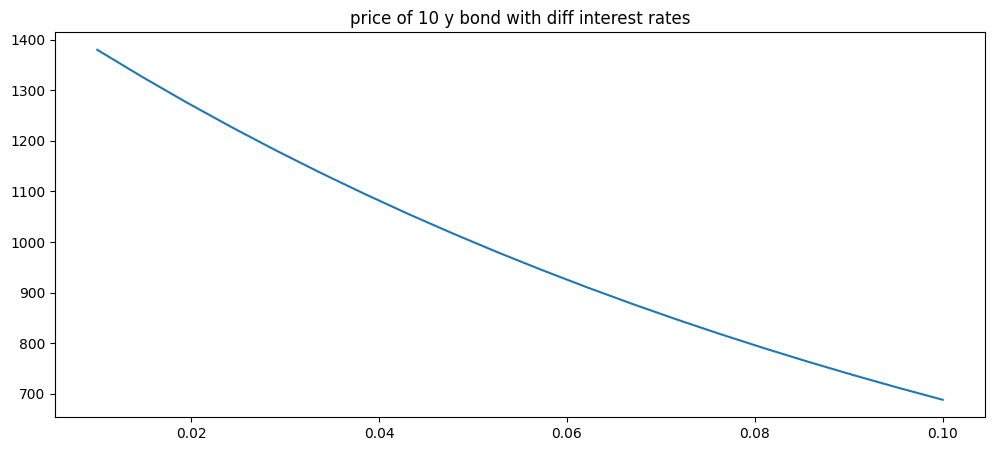

In [84]:
pd.DataFrame(data = prices, index=rates).plot(title="price of 10 y bond with diff interest rates", legend=None, figsize=(12,5))

In [85]:
cf = erk.bond_cash_flows(3 , 1000, 0.06, 2)
cf

1      30.0
2      30.0
3      30.0
4      30.0
5      30.0
6    1030.0
dtype: float64

In [86]:
discounts = erk.discount(cf.index, 0.06/2)
discounts

Index([ 0.970873786407767, 0.9425959091337544, 0.9151416593531595,
       0.8884870479156888, 0.8626087843841639, 0.8374842566836542],
      dtype='float64')

In [87]:
dcf = discounts*cf
dcf

1     29.126214
2     28.277877
3     27.454250
4     26.654611
5     25.878264
6    862.608784
dtype: float64

In [88]:
weights =dcf/dcf.sum()
weights

1    0.029126
2    0.028278
3    0.027454
4    0.026655
5    0.025878
6    0.862609
dtype: float64

In [89]:
(cf.index*weights).sum()

np.float64(5.579707187194534)

In [90]:
erk.macaulay_duration(erk.bond_cash_flows(3,1000, 0.06,2), 0.06/2)

np.float64(5.579707187194534)

## duration Matching

In [91]:
liabilities = pd.Series(data=[10000, 10000], index= [10,12])
erk.macaulay_duration(liabilities, .04)

np.float64(10.960799385088393)

In [92]:
md10 = erk.macaulay_duration(erk.bond_cash_flows(10, 1000, .05, 1), 0.04)
md20 = erk.macaulay_duration(erk.bond_cash_flows(20, 1000, .05, 1), 0.04)

In [93]:
md10, md20

(np.float64(8.190898824083233), np.float64(13.544718122145921))

In [94]:
short_bond=erk.bond_cash_flows(10, 1000, 0.05, 1)
long_bond=erk.bond_cash_flows(20, 1000, 0.05, 1)
w_s = erk.match_durations(liabilities,short_bond, long_bond, 0.04)
w_s

np.float64(0.48263092069478974)

In [95]:
p_short = erk.bond_price( 10, 1000, 0.05, 1, .04)
p_long = erk.bond_price( 20, 1000, 0.05, 1, .04)
a_0 = 13000
p_flows = pd.concat([a_0*w_s*short_bond/p_short,a_0*(1-w_s)*long_bond/p_long])
erk.macaulay_duration(p_flows, 0.04)

np.float64(10.960799385088393)

In [96]:
erk.macaulay_duration(liabilities, 0.04)

np.float64(10.960799385088393)

In [97]:
cfr = erk.funding_ratio(p_flows, liabilities, 0.04)
cfr

np.float64(0.9998760012192476)

In [103]:
rates = np.linspace(0, 0.1, 20)
lb_assets = a_0*long_bond/p_long
sb_assets = a_0*short_bond/p_short
fr_change = pd.DataFrame({
    "Long Bond":[erk.funding_ratio(lb_assets, liabilities, r) for r in rates],
    "short Bond":[erk.funding_ratio(sb_assets, liabilities, r) for r in rates],
    "Duration Matched Bonds":[erk.funding_ratio(p_flows, liabilities, r) for r in rates],
}, index=rates)

<Axes: title={'center': 'Funding Ratios with changes in interest Rats'}>

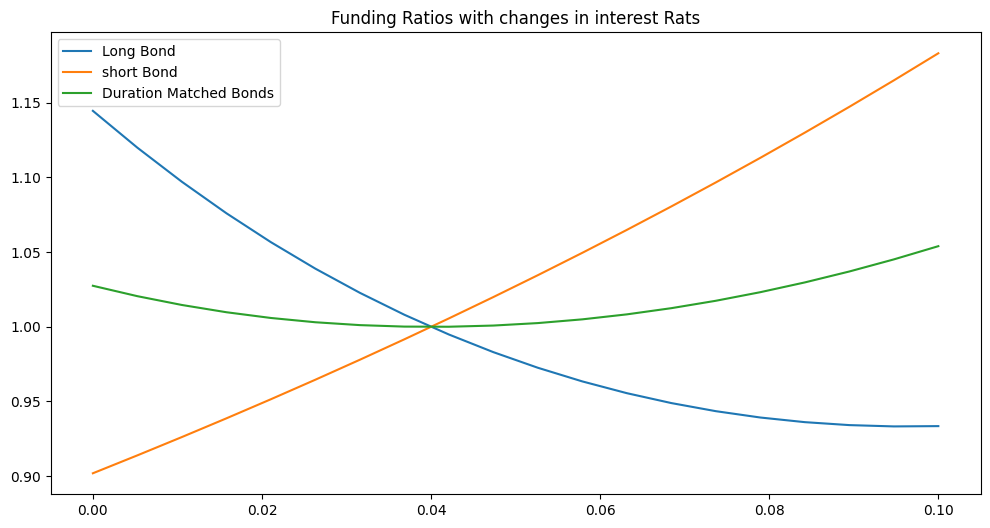

In [104]:
fr_change.plot(title="Funding Ratios with changes in interest Rats", figsize=(12,6))